# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 34     |  |
| :-------------|:-------------|
| Sybren Kuijlaars| 6540414 |
| Vera Reeringh | 6321046 |
| Cedric Peignier | 6577458 |

| Planning Groep: 34     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | Voor 12:30 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| Voor 14:30 |
| Pauze 1| 12:30 - 13:30 |
| Pauze 2| 15:30-15:55 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](Schetsen.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
| LDR | Lamp aan-/uit- zetten | Licht led moet niet worden meegenomen |
| LDR | Lamp aan-/uit- zetten | Moet van 0 tot 500 Lumen kunnen meten |
| LDR | Lamp aan-/uit- zetten | Drempelwaarde lichtintensiteit = 300 Lumen |
| Thermisch | Temperatuurverandering bij lichtconcentratie | Geen extern licht naast de te meten lichtbron |
| Thermisch | Temperatuurverandering bij lichtconcentratie | Moet licht concentreren dmv glas of spiegels tot een punt: de sensor |
| Thermisch | Temperatuurverandering bij lichtconcentratie | Moet tussen 288 - 318 K kunnen meten|
| Druk | Fietsen tellen | Moet tussen 50 en 300 N kunnen meten en weerstaan |
| Druk | Fietsen tellen | Moet op dezelfde plek blijven |
| Druk | Fietsen tellen | Moet 2 fietsbanden binnen 5 seconden als 1 meting rekenen|

Groep 34 heeft gekozen voor sensor LDR . 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](eindschets.jpeg "schets student")

Hierboven is de gebouwde opstelling te zien. De LED is verbonden met de 220 $\Omega$ weerstand (R1) en de LDR met de 10 k $\Omega$ weerstand (R2)

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
2. Over welk bereik ga je deze variabelen veranderen?
3. Wat ga je allemaal meten?
4. Hoeveel metingen ga je doen?
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?


**Antwoorden**

1. We gaan de variabele locatie veranderen, waarbij de variabele licht wordt gemeten
2. 
3. We gaan het licht in verschillende kamers in het TN-gebouw meten
4. We gaan 5 metingen doen
5. Ja

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt]( Meetopstelling1.jpeg "meetopstelling student")
 ![Alt]( Meetopstelling2.jpeg "meetopstelling student")

Hierboven is de meetopstelling van twee kanten te zien, zodat de pins en de breadboardposities duidelijk te zien zijn

## *Opdracht 6*: Meten en fitten, Leerdoel

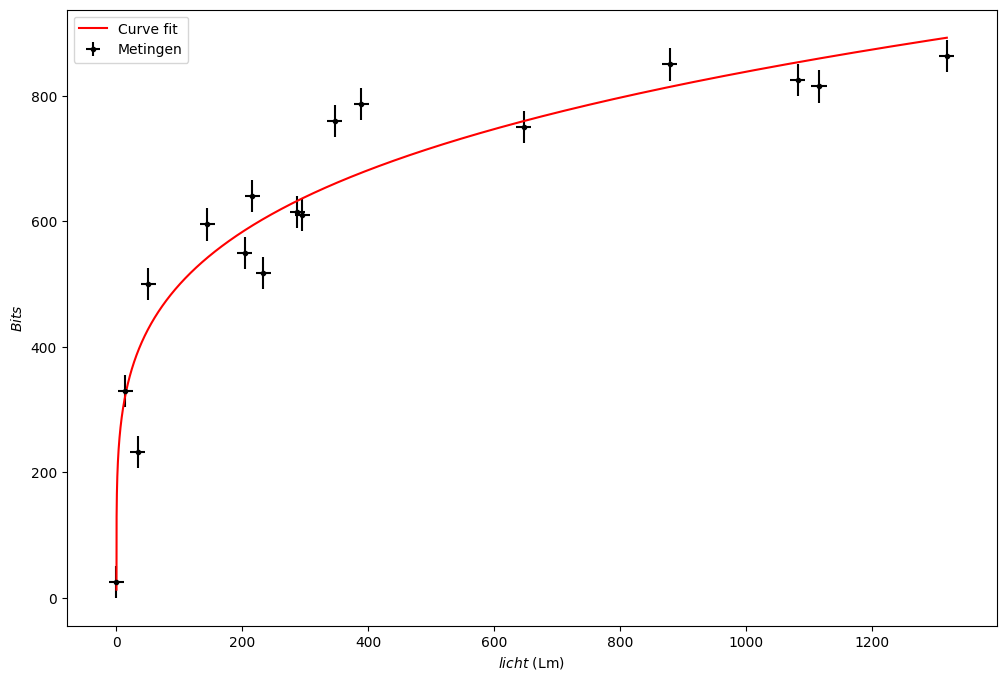

[168.74359417   0.22977681  13.17247276]


In [38]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Arduino_Meting = np.array([850,760,864,26,640,787,610,233,518,615,550,750,815,825,500,595,330])
Arduino_Onzekerheid = 12
Phyphox_Meting = np.array([879,347,1319,0,216,389,295,34,233,287,204,647,1116,1082,50.4,144,14])

# onzekerheid phyphox berekenen met standaarddeviatie

# metingen met lichtsensor phyphox in SC1 op rondom hetzelfde punt (een straal van ongeveer 25 cm)
x = np.array([813.5, 836.9, 1002, 926.8, 1004.8, 907.0, 891.8, 808.0])
sigma = np.std (x)
N = len(x) # aantal metingen

Phyphox_Onzekerheid = sigma / (np.sqrt(N)) # onzekerheid phyphox met standaarddeviatie

def fitfunc(x,a,b,c):
    return a * x**b + c

var, cov = curve_fit(fitfunc,Phyphox_Meting,Arduino_Meting)

xfit = np.linspace(np.min(Phyphox_Meting),np.max(Phyphox_Meting),100000)
yfit = fitfunc(xfit,var[0],var[1],var[2])

plt.figure(figsize=(12,8))
plt.errorbar(Phyphox_Meting,Arduino_Meting,Phyphox_Onzekerheid,Arduino_Onzekerheid,'k.',label="Metingen")
plt.plot(xfit,yfit,'r-',label="Curve fit")
plt.xlabel("$licht$ (Lm)")
plt.ylabel("$Bits$")
plt.legend()
plt.show()

print(var)

De plot staat niet in een specifieke scale, dit is omdat het er niet duidelijker van wordt. De fit function die er uiteindelijk uit is gekomen geeft namelijk geen mooi verband voor ook maar elke scale, we hebben een log, wortel en enkele andere scales geprobeerd.

 ![Alt]( Scale_foto_1.jpeg "meetopstelling student")
 ![Alt]( Scale_foto_2.jpeg "meetopstelling student")
 ![Alt]( Scale_foto_3.jpeg "meetopstelling student")

## *Opdracht 7*: Iteratie nodig?

We hebben gaan nog een paar extra metingen doen in het interval waar we weinig metingen hebben, om er zeker van te zijn dat de fit klopt en om te checken of het niet toch een lineair verband bestaat. We hebben nog een paar metingen in SC1 gedaan met en zonder de flashlight, en in de doos.

## *Opdracht 8*: Conclusie, leerdoel

Vervang deze tekst door jouw conclusie. 

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.